# 🤖 Gün 2 — Yapay Zekâ ve Makine Öğrenmesi
### STEAM Yaz Kampı 2026 • Veri Bilimi Günü

Dün veride örüntüler gördük. Bugün bilgisayara o örüntüleri **kendi kendine öğretip tahmin** yaptıracağız.

---
### 📌 Hatırlatma
- Hücreleri **yukarıdan aşağıya sırayla** çalıştır (▶️ veya **Shift + Enter**).
- Bugün çoğu hücre **kendi kendine çalışır** — sen sonuçlara bakıp Çalışma Kitapçığı'nı dolduracaksın.

| İşaret | Anlamı |
|--------|--------|
| ✏️ | Sen değiştir |
| 📝 | Çalışma Kitapçığı'na yaz |
| 🧑‍🏫 | Öğretmen / cevap anahtarı |
| 💡 | İpucu |
| ⚠️ | Dikkat |

> 🤖 **Bu, defterin "çıktılı önizleme" sürümüdür.** Asıl çalışacağınız Colab defteri
> [`notebooks/`](../notebooks) klasöründe. Buraya, normal hücrelerin **arasına**:
> 🔧 *deneyebileceğiniz varyasyonlar* (çalıştırılmış hâlde), 📊 *sonuçların nasıl
> yorumlanacağı* ve mini projelerde 🎤 *sunum rehberleri* eklendi. Bu eklemeler
> **yeşil/gri kutularla** ayrılmıştır; siz de aynı şeyleri kendi defterinizde deneyebilirsiniz.


---
## 0. Hazırlık (dünkü gibi)
Çalıştır, Google hesabınla giriş yap.

In [2]:
import os
from python_code.helper_tr import *
import pandas as pd
print('✅ Hazırız!')


✅ Hazırız!


---
## 1. Boy–Ayakkabı Oyunu — Makine Öğrenmesi Nedir?
### 📝 Çalışma Kitapçığı — Gün 2, Bölüm 1

Öğretmenin tahtaya 5 öğrencinin **boyunu** ve **ayakkabı numarasını** yazdı. 6. öğrencinin boyuna bakıp ayakkabı numarasını **tahmin** ettin.

Yaptığın şey: *eski örneklere bakıp yeni bir örnek için kestirimde bulunmak.* **İşte makine öğrenmesi tam olarak budur!**

**📝** Tahminini, gerçek sonucu ve hangi ipuçlarını kullandığını Çalışma Kitapçığı'na yaz.

### İki tür görev
| Tür | Soru | Örnek |
|-----|------|-------|
| **Sınıflandırma** | Hangi gruba ait? | Bu penguen hangi tür? Bu mantar zehirli mi? |
| **Regresyon** | Sayı kaç olacak? | Yarın kaç derece? Bu evin fiyatı? |

### Eğitim ve test — neden ayırırız?
Bir öğrenci geçen yılki soruları **ezberlerse**, aynı sorularda 100 alır ama yeni soruda zorlanır.
Bilgisayar da öyle: bir kısım veriyle **öğretiriz (eğitim)**, görmediği kısımla **sınarız (test)**. Genelde %80 eğitim, %20 test.

---
## 2. Penguen Sınıflandırma 🐧
### 📝 Çalışma Kitapçığı — Gün 2, Bölüm 2

**Veri:** 333 penguen, 3 tür (Adelie / Chinstrap / Gentoo). Ölçümlerden (gaga, kanat, ağırlık...) türü tahmin edeceğiz.

In [3]:
penguen = veri_yukle('input_data/penguenler.csv')
print('\nHangi türden kaç tane var?')
print(penguen['tur'].value_counts())

📂 'input_data/penguenler.csv' okunuyor...
✅ Yüklendi: 333 satır × 7 sütun

İlk 5 satır:
      tur        ada  gaga_uzunluk_mm  gaga_derinlik_mm  kanat_uzunluk_mm  \
0  Adelie  Torgersen             39.1              18.7             181.0   
1  Adelie  Torgersen             39.5              17.4             186.0   
2  Adelie  Torgersen             40.3              18.0             195.0   
3  Adelie  Torgersen             36.7              19.3             193.0   
4  Adelie  Torgersen             39.3              20.6             190.0   

   vucut_agirlik_g cinsiyet  
0           3750.0    erkek  
1           3800.0     dişi  
2           3250.0     dişi  
3           3450.0     dişi  
4           3650.0    erkek  

Hangi türden kaç tane var?
tur
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


Önce gözle bakalım: iki ölçüme göre türler ayrışıyor mu?

📈 Dağılım grafiği çiziliyor: gaga_uzunluk_mm - vucut_agirlik_g


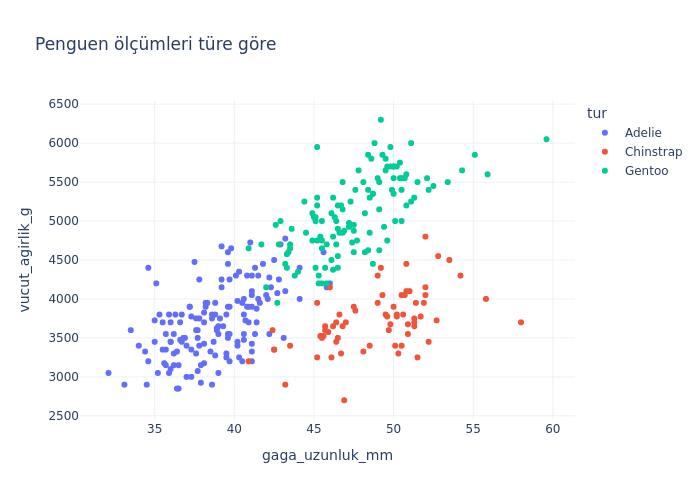

In [4]:
dagilim_grafigi(penguen, x_sutunu='gaga_uzunluk_mm', y_sutunu='vucut_agirlik_g',
                renk_sutunu='tur', baslik='Penguen ölçümleri türe göre')

🔧 **Farklı iki ölçümle dene.** Türleri ayıran tek ölçüm yok. Başka iki sütun seçip ayrışmanın hâlâ olup olmadığına bak — modelin işini bu yüzden kolaylaştırırız:

📈 Dağılım grafiği çiziliyor: kanat_uzunluk_mm - gaga_derinlik_mm


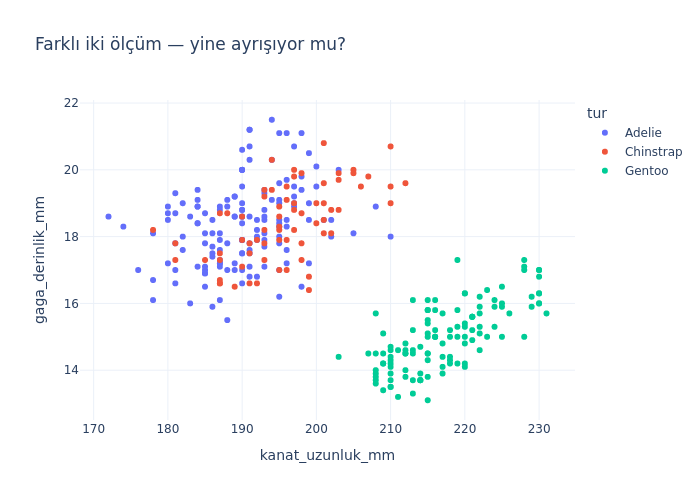

In [5]:
dagilim_grafigi(penguen, x_sutunu='kanat_uzunluk_mm', y_sutunu='gaga_derinlik_mm',
                renk_sutunu='tur', baslik='Farklı iki ölçüm — yine ayrışıyor mu?')

📊 **Nasıl yorumlanır?** Renk grupları (türler) **ayrı kümeler** oluşturuyorsa, o iki ölçüm türü ayırmak için *iyi ipuçlarıdır*. Kümeler iç içeyse o ölçümler tek başına yetersizdir. Model de tam olarak bunu yapar: en iyi ayıran ipuçlarını bulur.

### Veriyi modele hazırla
Modeller **sayı** ister, yazı sevmez. `ada` ve `cinsiyet` sütunları yazı — onları sayıya çeviriyoruz (`get_dummies`). Sonra veriyi eğitim/test diye ikiye bölüyoruz.

In [6]:
# tur = tahmin etmek istediğimiz hedef; geri kalanı ipuçları (öznitelikler)
X = pd.get_dummies(penguen.drop(columns=['tur']), columns=['ada', 'cinsiyet'])
y = penguen['tur']
X_egitim, X_test, y_egitim, y_test = egitim_test_bol(X, y)

🪓 Eğitim: 266 örnek | Test: 67 örnek


### Karar ağacını eğit
**Karar ağacı**, "Eğer kanat > 207 ise... değilse..." gibi sorularla karar veren bir modeldir. En güzel yanı: **çizebiliriz ve kararlarını anlayabiliriz.**

In [7]:
model = karar_agaci_egit(X_egitim, y_egitim, max_derinlik=3)
karar_agaci_ciz(model, oznitelik_adlari=list(X.columns), sinif_adlari=list(model.classes_))

🌳 Karar ağacı eğitiliyor (max_derinlik=3)...
✅ Eğitim tamamlandı.


🔧 **Aynı veriye farklı model.** Tek bir karar ağacı yerine **rastgele orman** (yüzlerce ağacın oyu) deneyelim ve doğruluğu karşılaştıralım:

In [8]:
orman = rastgele_orman_egit(X_egitim, y_egitim)
model_degerlendir(orman, X_test, y_test, sinif_adlari=list(orman.classes_))

🌲🌲🌲 Rastgele orman eğitiliyor (100 ağaç)...


✅ Eğitim tamamlandı.
🎯 Doğruluk: %100.00


1.0

📊 **Nasıl yorumlanır?** Rastgele orman çoğu zaman tek ağaçtan **biraz daha doğrudur**, çünkü birçok ağacın hatası birbirini dengeler. Bedeli: artık tek bir resimle çizemeyiz — yani **daha doğru ama daha az “açıklanabilir”**. Doğruluk mu, anlaşılırlık mı? Bu bir **ödünleşimdir (trade-off)** ve probleme göre seçilir (örn. tıpta açıklanabilirlik çok önemli).

**📝** Ağacın **en üstteki** (kök) sorusunda hangi ölçüm var? Bu, türleri en iyi ayıran ölçüdür. Çalışma Kitapçığı'na yaz.

### Model ne kadar başarılı?
Test verisinde doğruluğu ve **karmaşıklık matrisini** (hangi türü neyle karıştırdığını) görelim.

In [9]:
dogruluk = model_degerlendir(model, X_test, y_test, sinif_adlari=list(model.classes_))

🎯 Doğruluk: %98.51


**📝** Karmaşıklık matrisinin köşegen DIŞINDAKİ sayılar yanlış tahminlerdir. Model **en çok hangi iki türü** karıştırıyor? Çalışma Kitapçığı'na yaz.

Hangi ölçüm en önemliymiş? Modele soralım:

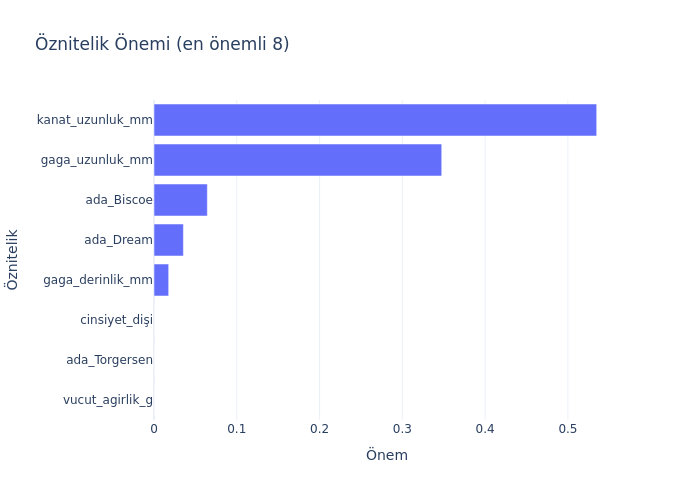

In [10]:
oznitelik_onemi_grafigi(model, oznitelik_adlari=list(X.columns), en_iyi_n=8)

### Aşırı öğrenme (overfitting) deneyi
Ağacı daha **derin** yaparsak ne olur? Eğitim ve test doğruluğunu karşılaştıralım.

In [11]:
for derinlik in [1, 2, 5, 15]:
    m = karar_agaci_egit(X_egitim, y_egitim, max_derinlik=derinlik)
    egitim_skoru = m.score(X_egitim, y_egitim) * 100
    test_skoru   = m.score(X_test,   y_test)   * 100
    print(f'Derinlik {derinlik:2d}  →  Eğitim: %{egitim_skoru:.0f}   Test: %{test_skoru:.0f}')

🌳 Karar ağacı eğitiliyor (max_derinlik=1)...
✅ Eğitim tamamlandı.
Derinlik  1  →  Eğitim: %78   Test: %81
🌳 Karar ağacı eğitiliyor (max_derinlik=2)...
✅ Eğitim tamamlandı.
Derinlik  2  →  Eğitim: %96   Test: %99
🌳 Karar ağacı eğitiliyor (max_derinlik=5)...
✅ Eğitim tamamlandı.
Derinlik  5  →  Eğitim: %100   Test: %100
🌳 Karar ağacı eğitiliyor (max_derinlik=15)...
✅ Eğitim tamamlandı.
Derinlik 15  →  Eğitim: %100   Test: %100


📊 **Yukarıdaki tabloyu nasıl okumalı? (Aşırı öğrenme / overfitting)** Derinlik arttıkça **Eğitim** doğruluğu genelde %100'e tırmanır — ağaç eğitim verisini *ezberler*. Ama asıl önemli olan **Test** sütunudur (modelin hiç görmediği veri). Eğitim yüksek ama test düşükse, model **ezberlemiş ama öğrenememiştir**. En iyi derinlik, *testin en yüksek olduğu* yerdir — daha fazlası işi bozar. Bu, makine öğrenmesinin en önemli dersidir. 🧠

**📝** Ağaç derinliğini artırınca **eğitim** doğruluğu ne oldu, **test** doğruluğu ne oldu? Çalışma Kitapçığı'na yaz.

💡 Ağaç çok derinleşince eğitim verisini **ezberler** (%100) ama yeni veride daha iyi olmaz. Buna **aşırı öğrenme** denir — tıpkı soruları ezberlemek gibi.

🧑‍🏫 **Cevap anahtarı:** Kök düğüm genelde **kanat_uzunluk_mm** (Gentoo en büyük tür). En çok karışan: **Adelie ↔ Chinstrap** (ikisi de küçük). Derinlik arttıkça eğitim %100'e çıkar, test ~%97'de durur → aşırı öğrenme.

---
## 3. Mantar: Yenir mi, Zehirli mi? 🍄 — Etik Tartışma
### 📝 Çalışma Kitapçığı — Gün 2, Bölüm 3

Aynı işi **çok farklı** bir veriyle yapalım: 1500 mantar, hepsi yazı (kategori) ipuçları — şapka rengi, **koku**, habitat...

⚠️ **Bu sadece eğitim verisidir!** Gerçekte mantar tanımak için ASLA bir modele güvenme — uzmana sor.

In [12]:
mantar = veri_yukle('input_data/mantarlar.csv')
print('\nKaç yenir, kaç zehirli?')
print(mantar['sinif'].value_counts())

📂 'input_data/mantarlar.csv' okunuyor...
✅ Yüklendi: 1500 satır × 7 sütun

İlk 5 satır:
  sapka_rengi sapka_sekli solungac_rengi       koku  habitat halka_tipi  \
0        sarı     içbükey          beyaz  baharatlı    orman        tek   
1         gri         düz          beyaz    kokusuz  odunluk        yok   
2  kahverengi    yuvarlak     kahverengi  baharatlı    çayır        tek   
3  kahverengi    yuvarlak     kahverengi    kreosot    bahçe        tek   
4       beyaz    yuvarlak          beyaz    kokusuz    orman      asılı   

     sinif  
0  zehirli  
1  zehirli  
2  zehirli  
3  zehirli  
4    yenir  

Kaç yenir, kaç zehirli?
sinif
zehirli    1083
yenir       417
Name: count, dtype: int64


Tüm ipuçları yazı olduğu için hepsini sayıya çeviriyoruz, sonra modeli eğitip değerlendiriyoruz.

🪓 Eğitim: 1200 örnek | Test: 300 örnek
🌳 Karar ağacı eğitiliyor (max_derinlik=4)...
✅ Eğitim tamamlandı.
🎯 Doğruluk: %83.67


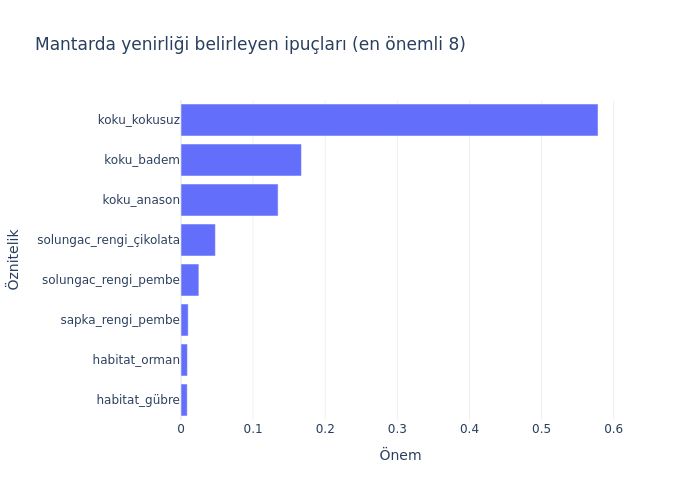

In [13]:
X_m = pd.get_dummies(mantar.drop(columns=['sinif']))
y_m = mantar['sinif']
X_m_eg, X_m_te, y_m_eg, y_m_te = egitim_test_bol(X_m, y_m)

model_m = karar_agaci_egit(X_m_eg, y_m_eg, max_derinlik=4)
model_degerlendir(model_m, X_m_te, y_m_te, sinif_adlari=list(model_m.classes_))
oznitelik_onemi_grafigi(model_m, oznitelik_adlari=list(X_m.columns), en_iyi_n=8,
                        baslik='Mantarda yenirliği belirleyen ipuçları')

### 🤔 Etik tartışma — sınıfça konuşun
Modelin iki tür hatası olabilir:
- **Yanlış "yenir" dedi** (gerçekte zehirli) → birisi yiyebilir → **tehlike!** ☠️
- **Yanlış "zehirli" dedi** (gerçekte yenir) → sadece yemek çöpe gider 🗑️

**📝** Bu iki hata aynı derecede kötü mü? Sence hangisi daha kötü, neden? Çalışma Kitapçığı'na yaz.

🧑‍🏫 **Yön ver:** En önemli ipucu **koku**. Yanlış "yenir" (zehirliyi kaçırmak) ölümcül olabilir → model bundan emin olana kadar "yenir" dememeli. Aynı mantık tıpta (kanser teşhisi), adalette, kredide de geçerli.

---
## 4. Malatya Hava Tahmini — Regresyon 🌤️
### 📝 Çalışma Kitapçığı — Gün 2, Bölüm 4

Şimdi **sayı tahmin** edeceğiz (sınıf değil): geçmiş günlere bakıp **yarınki ortalama sıcaklığı** kestireceğiz.

📂 'input_data/malatya_hava.csv' okunuyor...
✅ Yüklendi: 1827 satır × 11 sütun

İlk 5 satır:
        tarih  sicaklik_max  sicaklik_min  sicaklik_ort  yagis  ruzgar_max  \
0  2020-01-01           7.0           0.1           2.9    0.0         8.9   
1  2020-01-02           4.2          -0.7           2.1    0.5         4.0   
2  2020-01-03           2.9           1.8           2.2    6.5         5.6   
3  2020-01-04           4.4           1.3           2.4    4.6         6.0   
4  2020-01-05           2.2           0.6           1.2   10.6        10.1   

    yil  ay  gun hafta_gunu mevsim  
0  2020   1    1  Wednesday    Kış  
1  2020   1    2   Thursday    Kış  
2  2020   1    3     Friday    Kış  
3  2020   1    4   Saturday    Kış  
4  2020   1    5     Sunday    Kış  


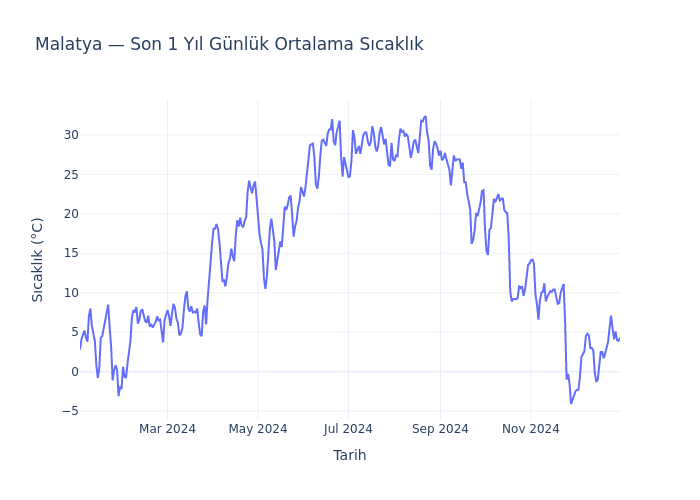

In [14]:
hava = veri_yukle('input_data/malatya_hava.csv')
hava['tarih'] = pd.to_datetime(hava['tarih'])

# son 1 yılın sıcaklık grafiği
import plotly.express as px
fig = px.line(hava.tail(365), x='tarih', y='sicaklik_ort',
              title='Malatya — Son 1 Yıl Günlük Ortalama Sıcaklık',
              labels={'tarih':'Tarih','sicaklik_ort':'Sıcaklık (°C)'})
fig.show()

**Fikir:** Bilgisayara "dünün, 2 gün öncenin, 7 gün öncenin" sıcaklığını verip yarını tahmin ettireceğiz (buna *gecikme öznitelikleri* denir). 2020–2023 ile **öğretiyoruz**, 2024 ile **sınıyoruz**.

📏 Lineer regresyon eğitiliyor...
✅ Eğitim tamamlandı.
📊 RMSE (kök ortalama kare hata): 1.539
📊 MAE  (ortalama mutlak hata) : 1.184
📊 R²   (açıklanan varyans)    : 0.977


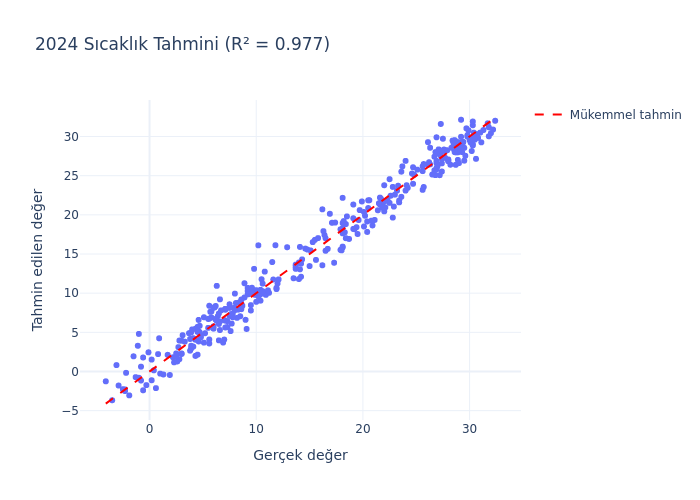

In [15]:
hava = hava.sort_values('tarih').reset_index(drop=True)
for gun in [1, 2, 3, 7]:
    hava[f'sicaklik_oncesi_{gun}gun'] = hava['sicaklik_ort'].shift(gun)
hava_temiz = hava.dropna()

ozellikler = ['sicaklik_oncesi_1gun','sicaklik_oncesi_2gun',
              'sicaklik_oncesi_3gun','sicaklik_oncesi_7gun','ay']
X_h = hava_temiz[ozellikler]
y_h = hava_temiz['sicaklik_ort']

egitim = hava_temiz['yil'] < 2024          # 2020-2023 öğret, 2024 sına
model_h = lineer_regresyon_egit(X_h[egitim], y_h[egitim])
metrikler = regresyon_degerlendir(model_h, X_h[~egitim], y_h[~egitim],
                                  baslik='2024 Sıcaklık Tahmini')

📊 **Regresyon sonuçları nasıl yorumlanır?** Burada bir *sayı* tahmin ediyoruz, sınıf değil. Üç ölçüye bakın: **RMSE** = ortalama kaç derece yanıldık (küçük = iyi); **MAE** = benzer ama uç hatalara daha az duyarlı; **R²** = modelin değişimi ne kadar açıkladığı (1'e yakın = iyi, 0 = ortalamayı söylemekten farksız). Grafikte noktalar kırmızı **y=x çizgisine** ne kadar yakınsa tahmin o kadar iyidir. 'Dünün sıcaklığı' gibi basit ipuçlarıyla bile yarını şaşırtıcı derecede iyi tahmin edebiliyoruz — çünkü hava *kademeli* değişir.

**📝** Çıkan **RMSE** kaç °C? ("Ortalama bu kadar yanılıyoruz" demek.) **R²** kaç? Bir yorum yazıp Çalışma Kitapçığı'ndaki tabloyu doldur.

💡 2°C hata nerede sorun olur — tarımda mı (don riski), klima ayarında mı? Tartışın.

🧑‍🏫 **Cevap:** RMSE ≈ **1.5 °C**, R² ≈ **0.97**. "Yarın bugüne yakın olur" sezgisi çok güçlü çünkü hava yavaş değişir.

---
## 5. Kavram Sözlüğü — Kendi Kelimelerinle
### 📝 Çalışma Kitapçığı — Gün 2, Bölüm 5

Aşağıdaki kavramları **kendi cümlelerinle** Çalışma Kitapçığı'na yaz. (Aşağısı sadece hatırlatma.)

- **Sınıflandırma:** Bir şeyin hangi gruba/kategoriye ait olduğunu tahmin etmek. *(penguen türü, mantar yenir/zehirli)*
- **Regresyon:** Bir **sayıyı** tahmin etmek. *(yarınki sıcaklık)*
- **Aşırı öğrenme (overfitting):** Modelin eğitim verisini ezberleyip yeni veride başarısız olması.
- **Eğitim / test farkı:** Eğitim = öğretmek için; test = modelin **görmediği** veriyle gerçek başarısını ölçmek.

---
## 6. Mini Proje Tercihi 🎯
### 📝 Çalışma Kitapçığı — Gün 2, Bölüm 6

İki günlük eğitimi tamamladın! 🎉 Şimdi grupça **bir mini proje** seçeceksiniz. Bu projeyi kampın **son günündeki "Bilimsel Yöntem" oturumunda** sunacaksınız.

| # | Proje | Tür | Defter |
|---|-------|-----|--------|
| 1 | 🪐 Uzay — Ötegezegen tespiti (NASA) | Sınıflandırma | `mini_proje1_uzay.ipynb` |
| 2 | 🩺 Sağlık — Göğüs kanseri teşhisi | Sınıflandırma (etik) | `mini_proje2_saglik.ipynb` |
| 3 | 🌍 İklim — CO₂ ve sıcaklık | Regresyon | `mini_proje3_iklim.ipynb` |
| 4 | 🎤 Eurovision — şarkı yarışması | Sınıflandırma + analiz | `mini_proje4_eurovision.ipynb` |
| 5 | 🌤️ Hava — Malatya gelişmiş tahmin | Regresyon | `mini_proje5_hava.ipynb` |

**📝 Grupça karar verin (5 dk):** Hangi konu en çok ilginizi çekiyor? **Seçtiğiniz veri setini** ve **araştırma sorunuzun taslağını** Çalışma Kitapçığı'na yazın. Sonra ilgili `mini_proje...` defterini açıp keşfe başlayabilirsiniz.

---
## ✅ Gün 2 Özeti
Bugün öğrendiklerin:
- ✅ **Sınıflandırma** (penguen, mantar) ve **Regresyon** (sıcaklık)
- ✅ **Eğitim / test** ayrımı ve neden gerekli
- ✅ **Doğruluk, RMSE, R²** — başarıyı ölçmek
- ✅ **Karmaşıklık matrisi** — model nerede yanılıyor
- ✅ **Aşırı öğrenme** — ezberleyen model genelleyemez
- ✅ **Etik** — yanlış tahminin bedeli her zaman aynı değil

Çok iyiydiniz! Seçtiğiniz projeyi son gün sunacaksınız — başarılar! 👋

---
## 🆘 Sık karşılaşılan hatalar
- **`FileNotFoundError`** → Drive bağlandı mı? 0. Hazırlık hücresini çalıştırdın mı?
- **`could not convert string to float`** → Modele yazı verdik; `pd.get_dummies(...)` ile sayıya çevir.
- **Doğruluk %100** → Çok güzel görünür ama genelde test verisi yoktur; `egitim_test_bol(...)` kullandın mı?
- **Ağaç okunmuyor** → `max_derinlik=3` veya `4` kullan; daha derini çok büyük olur.